# DORAEMON-Only (Paper-Inspired) Adaptation (Gym surrogate -> TinySim target)

This notebook removes BO and runs fixed-center DORAEMON adaptation only:
- bounded Beta DR distribution
- entropy-maximization under success constraint
- KL trust-region updates
- IS-based success estimates

Use this to compare against BO and BO+DR variants.

## 1) Imports and Global Setup

In [1]:
from __future__ import annotations

import csv
import json
import os
import random
import time
import copy
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from scipy.special import betaln, digamma

from tinysim.mountain_car import MountainCarEnv

In [2]:
# No BO dependency is needed in this notebook.
print('DORAEMON-only mode (no BO)')

DORAEMON-only mode (no BO)


## 2) Config (edit this cell)

- `TARGET_PARAMS` is used **only** for TinySim target evaluation.
- BO never gets direct access to target params beyond scalar target eval score.


In [4]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE:', DEVICE)

PROJECT_DIR = Path('/home/buchkeva/IdeaTesting/TinySim')
RUNS_ROOT = PROJECT_DIR / 'runs'
RUNS_ROOT.mkdir(parents=True, exist_ok=True)

WARMSTART_CHECKPOINT = PROJECT_DIR / 'mountain_car_saved' / 'mountain_car_dqn.pt'

DR_BOUNDS = {
    'force': (0.0003, 0.0030),
    'gravity': (0.0010, 0.0062),
}
EDGE_DR_BOUNDS = {
    'force': (0.0007, 0.0018),
    'gravity': (0.0030, 0.0059),
}

MU0 = np.array([0.0010, 0.0025], dtype=np.float32)
MU0_EDGE = np.array([
    float(np.clip(MU0[0], EDGE_DR_BOUNDS['force'][0], EDGE_DR_BOUNDS['force'][1])),
    float(np.clip(MU0[1], EDGE_DR_BOUNDS['gravity'][0], EDGE_DR_BOUNDS['gravity'][1])),
], dtype=np.float32)

# Fixed center for DORAEMON-only adaptation
ADAPT_CENTER = MU0_EDGE.copy()

TAU_STEPS = 300
ALPHA_TARGET = 0.60
KL_MAX = 0.04
C_INIT = np.array([18.0, 18.0], dtype=np.float32)
C_MIN = np.array([2.2, 2.2], dtype=np.float32)
C_MAX = np.array([220.0, 220.0], dtype=np.float32)
CANDIDATES_PER_UPDATE = 300
MEAN_PERTURB_STD = 0.06
LOGC_PERTURB_STD = 0.20
MIN_WEIGHT_LOG = -20.0
MAX_WEIGHT_LOG = 20.0

TARGET_PARAMS = {
    'force': 0.0010,
    'gravity': 0.0050,
}

# DORAEMON-only budgets
SMOKE_CFG = dict(adapt_iters=3, blocks=5, episodes_per_block=4, B_r=5)
PROTO_CFG = dict(adapt_iters=12, blocks=20, episodes_per_block=6, B_r=12)
EDGE_CFG = dict(adapt_iters=20, blocks=30, episodes_per_block=6, B_r=20)

print('Warmstart checkpoint:', WARMSTART_CHECKPOINT)
print('Target params (eval only):', TARGET_PARAMS)
print('ADAPT_CENTER:', ADAPT_CENTER.tolist())

DEVICE: cuda
Warmstart checkpoint: /home/buchkeva/IdeaTesting/TinySim/mountain_car_saved/mountain_car_dqn.pt
Target params (eval only): {'force': 0.001, 'gravity': 0.005}
ADAPT_CENTER: [0.0010000000474974513, 0.003000000026077032]


## 3) DQN Components (MountainCar)

In [5]:
class ReplayBuffer:
    def __init__(self, capacity: int = 10000):
        self.capacity = int(capacity)
        self.buffer = []
        self.pos = 0

    def push(self, state, action, reward, next_state, done):
        item = (
            np.asarray(state, dtype=np.float32),
            int(action),
            float(reward),
            np.asarray(next_state, dtype=np.float32),
            float(done),
        )
        if len(self.buffer) < self.capacity:
            self.buffer.append(item)
        else:
            self.buffer[self.pos] = item
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size: int, device: str):
        idx = np.random.choice(len(self.buffer), size=batch_size, replace=False)
        batch = [self.buffer[i] for i in idx]
        s, a, r, ns, d = zip(*batch)
        states = torch.tensor(np.stack(s), dtype=torch.float32, device=device)
        actions = torch.tensor(a, dtype=torch.long, device=device)
        rewards = torch.tensor(r, dtype=torch.float32, device=device)
        next_states = torch.tensor(np.stack(ns), dtype=torch.float32, device=device)
        dones = torch.tensor(d, dtype=torch.float32, device=device)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    def __init__(self, state_dim: int = 2, n_actions: int = 3, hidden_dim: int = 128):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


@dataclass
class DQNConfig:
    state_dim: int = 2
    n_actions: int = 3
    hidden_dim: int = 128
    lr: float = 1e-3
    gamma: float = 0.99
    epsilon_start: float = 1.0
    epsilon_end: float = 0.01
    epsilon_decay: float = 0.995
    buffer_capacity: int = 10000
    batch_size: int = 64
    target_update_freq: int = 10


class DQNAgent:
    def __init__(self, cfg: DQNConfig, device: str = 'cpu'):
        self.cfg = cfg
        self.device = device

        self.policy_net = QNetwork(cfg.state_dim, cfg.n_actions, cfg.hidden_dim).to(device)
        self.target_net = QNetwork(cfg.state_dim, cfg.n_actions, cfg.hidden_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=cfg.lr)
        self.memory = ReplayBuffer(cfg.buffer_capacity)

        self.epsilon = cfg.epsilon_start
        self.training_losses = []
        self._episode_counter = 0

    def act(self, state: np.ndarray, training: bool = True) -> int:
        if training and random.random() < self.epsilon:
            return random.randrange(self.cfg.n_actions)
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            q = self.policy_net(s)
            return int(q.argmax(dim=1).item())

    def store(self, s, a, r, ns, done):
        self.memory.push(s, a, r, ns, done)

    def learn_step(self):
        if len(self.memory) < self.cfg.batch_size:
            return None
        s, a, r, ns, d = self.memory.sample(self.cfg.batch_size, self.device)

        q = self.policy_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            nq = self.target_net(ns).max(dim=1)[0]
            target = r + self.cfg.gamma * nq * (1.0 - d)

        loss = nn.MSELoss()(q, target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()
        self.training_losses.append(float(loss.item()))
        return float(loss.item())

    def end_episode(self):
        self._episode_counter += 1
        self.epsilon = max(self.cfg.epsilon_end, self.epsilon * self.cfg.epsilon_decay)
        if (self._episode_counter % self.cfg.target_update_freq) == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

    def state_payload(self) -> dict[str, Any]:
        return {
            'policy_state_dict': self.policy_net.state_dict(),
            'target_state_dict': self.target_net.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'epsilon': self.epsilon,
            'training_losses': self.training_losses,
            'hparams': vars(self.cfg),
        }

    def load_payload(self, payload: dict[str, Any]):
        self.policy_net.load_state_dict(payload['policy_state_dict'])
        self.target_net.load_state_dict(payload.get('target_state_dict', payload['policy_state_dict']))
        if 'optimizer_state_dict' in payload:
            self.optimizer.load_state_dict(payload['optimizer_state_dict'])
        self.epsilon = float(payload.get('epsilon', self.cfg.epsilon_end))
        self.training_losses = list(payload.get('training_losses', []))


## 4) Warm-start and Checkpoint Helpers

In [6]:
def make_agent_from_hparams(hparams: dict | None, device: str = DEVICE) -> DQNAgent:
    if hparams is None:
        cfg = DQNConfig()
    else:
        cfg = DQNConfig(**{k: v for k, v in hparams.items() if k in DQNConfig.__annotations__})
    return DQNAgent(cfg=cfg, device=device)


def load_warmstart_agent(checkpoint_path: str | Path, device: str = DEVICE) -> DQNAgent:
    payload = torch.load(str(checkpoint_path), map_location=device)
    hparams = payload.get('hparams')
    agent = make_agent_from_hparams(hparams, device=device)
    agent.load_payload(payload)
    return agent


def save_agent_checkpoint(agent: DQNAgent, path: str | Path, extra: dict | None = None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = agent.state_payload()
    payload['extra'] = extra or {}
    torch.save(payload, str(path))


def clone_agent(agent: DQNAgent) -> DQNAgent:
    cloned = make_agent_from_hparams(vars(agent.cfg), device=agent.device)
    cloned.load_payload(agent.state_payload())
    return cloned


## 5) Environment and Evaluation Helpers

In [7]:
def make_gym_env(force: float, gravity: float, seed: int | None = None):
    env = gym.make('MountainCar-v0')
    env.reset(seed=seed)
    env.unwrapped.force = float(force)
    env.unwrapped.gravity = float(gravity)
    return env


def normalize_params(force: float, gravity: float, bounds: dict) -> np.ndarray:
    zf = (float(force) - bounds['force'][0]) / (bounds['force'][1] - bounds['force'][0])
    zg = (float(gravity) - bounds['gravity'][0]) / (bounds['gravity'][1] - bounds['gravity'][0])
    return np.array([zf, zg], dtype=np.float64)


def denormalize_params(z: np.ndarray, bounds: dict) -> tuple[float, float]:
    force = bounds['force'][0] + float(z[0]) * (bounds['force'][1] - bounds['force'][0])
    gravity = bounds['gravity'][0] + float(z[1]) * (bounds['gravity'][1] - bounds['gravity'][0])
    return float(force), float(gravity)


def beta_from_mean_conc(mean: np.ndarray, conc: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    m = np.clip(np.asarray(mean, dtype=np.float64), 1e-4, 1.0 - 1e-4)
    c = np.clip(np.asarray(conc, dtype=np.float64), 2.0001, None)
    a = m * c
    b = (1.0 - m) * c
    return a, b


def mean_conc_from_beta(alpha: np.ndarray, beta: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    a = np.asarray(alpha, dtype=np.float64)
    b = np.asarray(beta, dtype=np.float64)
    c = a + b
    m = a / np.clip(c, 1e-8, None)
    return m, c


def make_beta_dist_at_mu(mu: np.ndarray, conc: np.ndarray, bounds: dict) -> dict:
    mu = np.array([
        float(np.clip(mu[0], bounds['force'][0], bounds['force'][1])),
        float(np.clip(mu[1], bounds['gravity'][0], bounds['gravity'][1])),
    ], dtype=np.float64)
    z = normalize_params(mu[0], mu[1], bounds)
    a, b = beta_from_mean_conc(z, conc)
    return {'alpha': a, 'beta': b, 'bounds': bounds}


def beta_logpdf(z: np.ndarray, alpha: np.ndarray, beta: np.ndarray) -> np.ndarray:
    z = np.clip(np.asarray(z, dtype=np.float64), 1e-6, 1.0 - 1e-6)
    a = np.asarray(alpha, dtype=np.float64)
    b = np.asarray(beta, dtype=np.float64)
    return (a - 1.0) * np.log(z) + (b - 1.0) * np.log(1.0 - z) - betaln(a, b)


def beta_entropy(alpha: np.ndarray, beta: np.ndarray) -> np.ndarray:
    a = np.asarray(alpha, dtype=np.float64)
    b = np.asarray(beta, dtype=np.float64)
    return betaln(a, b) - (a - 1.0) * digamma(a) - (b - 1.0) * digamma(b) + (a + b - 2.0) * digamma(a + b)


def dist_entropy(dist: dict) -> float:
    h = beta_entropy(dist['alpha'], dist['beta'])
    s_force = np.log(dist['bounds']['force'][1] - dist['bounds']['force'][0])
    s_grav = np.log(dist['bounds']['gravity'][1] - dist['bounds']['gravity'][0])
    return float(np.sum(h) + s_force + s_grav)


def beta_kl(a0: np.ndarray, b0: np.ndarray, a1: np.ndarray, b1: np.ndarray) -> np.ndarray:
    return (
        betaln(a1, b1) - betaln(a0, b0)
        + (a0 - a1) * digamma(a0)
        + (b0 - b1) * digamma(b0)
        + (a1 + b1 - a0 - b0) * digamma(a0 + b0)
    )


def dist_kl(old: dict, new: dict) -> float:
    return float(np.sum(beta_kl(old['alpha'], old['beta'], new['alpha'], new['beta'])))


def sample_beta_params(dist: dict, rng: np.random.Generator):
    z = rng.beta(dist['alpha'], dist['beta'])
    z = np.clip(z, 1e-6, 1.0 - 1e-6)
    force, gravity = denormalize_params(z, dist['bounds'])
    return force, gravity, z.astype(np.float64)


def is_success_estimate(
    z_samples: np.ndarray,
    success: np.ndarray,
    old_dist: dict,
    new_dist: dict,
    min_log_w: float = -20.0,
    max_log_w: float = 20.0,
) -> float:
    if len(z_samples) == 0:
        return 0.0
    z = np.clip(np.asarray(z_samples, dtype=np.float64), 1e-6, 1.0 - 1e-6)
    s = np.asarray(success, dtype=np.float64)

    logp_old = np.sum(beta_logpdf(z, old_dist['alpha'], old_dist['beta']), axis=1)
    logp_new = np.sum(beta_logpdf(z, new_dist['alpha'], new_dist['beta']), axis=1)

    logw = np.clip(logp_new - logp_old, min_log_w, max_log_w)
    w = np.exp(logw - np.max(logw))
    w = w / np.clip(np.sum(w), 1e-12, None)
    return float(np.sum(w * s))


def doraemon_update_beta(
    old_dist: dict,
    z_samples: np.ndarray,
    success_samples: np.ndarray,
    alpha_target: float,
    kl_max: float,
    rng: np.random.Generator,
    n_candidates: int,
    mean_std: float,
    logc_std: float,
    c_min: np.ndarray,
    c_max: np.ndarray,
    min_log_w: float,
    max_log_w: float,
):
    m_old, c_old = mean_conc_from_beta(old_dist['alpha'], old_dist['beta'])

    candidates = [(m_old.copy(), c_old.copy())]
    for _ in range(int(n_candidates)):
        m = np.clip(m_old + rng.normal(0.0, mean_std, size=2), 1e-4, 1.0 - 1e-4)
        c = np.exp(np.log(np.clip(c_old, 1e-8, None)) + rng.normal(0.0, logc_std, size=2))
        c = np.clip(c, c_min, c_max)
        candidates.append((m, c))

    best_feasible = None
    backup = None

    for m, c in candidates:
        a_new, b_new = beta_from_mean_conc(m, c)
        cand = {'alpha': a_new, 'beta': b_new, 'bounds': old_dist['bounds']}

        kl = dist_kl(old_dist, cand)
        if kl > kl_max:
            continue

        g_hat = is_success_estimate(
            z_samples=z_samples,
            success=success_samples,
            old_dist=old_dist,
            new_dist=cand,
            min_log_w=min_log_w,
            max_log_w=max_log_w,
        )
        ent = dist_entropy(cand)

        if (backup is None) or (g_hat > backup['g_hat']) or (np.isclose(g_hat, backup['g_hat']) and ent > backup['entropy']):
            backup = {'dist': cand, 'g_hat': float(g_hat), 'entropy': float(ent), 'kl': float(kl), 'mode': 'backup_success'}

        if g_hat >= alpha_target:
            if (best_feasible is None) or (ent > best_feasible['entropy']):
                best_feasible = {'dist': cand, 'g_hat': float(g_hat), 'entropy': float(ent), 'kl': float(kl), 'mode': 'feasible_entropy'}

    if best_feasible is not None:
        return best_feasible['dist'], best_feasible
    if backup is not None:
        return backup['dist'], backup

    return old_dist, {'dist': old_dist, 'g_hat': 0.0, 'entropy': dist_entropy(old_dist), 'kl': 0.0, 'mode': 'no_candidate'}


def target_eval_tinysim_detailed(
    agent: DQNAgent,
    n_eval_target: int,
    max_steps: int,
    target_params: dict,
    seed: int,
) -> tuple[float, int, int]:
    successes = 0

    for ep in range(n_eval_target):
        sim_env = MountainCarEnv()
        sim_env.force = float(target_params['force'])
        sim_env.gravity = float(target_params['gravity'])

        state = sim_env.reset()
        obs = np.array([state['position'], state['velocity']], dtype=np.float32)

        solved = False
        for _ in range(max_steps):
            a = agent.act(obs, training=False)
            state = sim_env.step(a)
            obs = np.array([state['position'], state['velocity']], dtype=np.float32)
            if bool(state['done']):
                solved = True
                break

        successes += int(solved)

    rate = float(successes / max(1, n_eval_target))
    return rate, int(successes), int(n_eval_target)


def target_eval_tinysim(
    agent: DQNAgent,
    n_eval_target: int,
    max_steps: int,
    target_params: dict,
    seed: int,
) -> float:
    rate, _, _ = target_eval_tinysim_detailed(
        agent=agent,
        n_eval_target=n_eval_target,
        max_steps=max_steps,
        target_params=target_params,
        seed=seed,
    )
    return float(rate)

## 6) DORAEMON Adaptation Under DR

In [8]:
def train_under_doraemon_beta(
    agent: DQNAgent,
    mu: np.ndarray,
    conc_init: np.ndarray,
    blocks: int,
    episodes_per_block: int,
    bounds: dict,
    tau_steps: int,
    alpha_target: float,
    kl_max: float,
    n_candidates: int,
    mean_std: float,
    logc_std: float,
    c_min: np.ndarray,
    c_max: np.ndarray,
    min_log_w: float,
    max_log_w: float,
    seed: int,
):
    rng = np.random.default_rng(seed)
    dist = make_beta_dist_at_mu(mu, conc_init, bounds)

    g_history = []
    conc_history = []
    block_history = []

    for b in range(int(blocks)):
        z_batch = []
        s_batch = []
        loss_batch = []

        for e in range(int(episodes_per_block)):
            force_e, gravity_e, z_e = sample_beta_params(dist, rng)

            env = make_gym_env(force=force_e, gravity=gravity_e, seed=seed + 1000 * (b + 1) + e)
            s, _ = env.reset(seed=seed + 1000 * (b + 1) + e)
            losses = []
            solved = False

            for _ in range(tau_steps):
                a = agent.act(s, training=True)
                ns, r, terminated, truncated, _ = env.step(a)
                done = terminated or truncated
                agent.store(s, a, r, ns, float(done))
                loss = agent.learn_step()
                if loss is not None:
                    losses.append(loss)
                s = ns
                if terminated:
                    solved = True
                    break
                if truncated:
                    break

            env.close()
            agent.end_episode()

            z_batch.append(z_e)
            s_batch.append(1.0 if solved else 0.0)
            if len(losses):
                loss_batch.append(float(np.mean(losses)))

        z_batch = np.asarray(z_batch, dtype=np.float64)
        s_batch = np.asarray(s_batch, dtype=np.float64)

        dist, upd = doraemon_update_beta(
            old_dist=dist,
            z_samples=z_batch,
            success_samples=s_batch,
            alpha_target=alpha_target,
            kl_max=kl_max,
            rng=rng,
            n_candidates=n_candidates,
            mean_std=mean_std,
            logc_std=logc_std,
            c_min=np.asarray(c_min, dtype=np.float64),
            c_max=np.asarray(c_max, dtype=np.float64),
            min_log_w=min_log_w,
            max_log_w=max_log_w,
        )

        _, conc_end = mean_conc_from_beta(dist['alpha'], dist['beta'])
        g_history.append(float(upd['g_hat']))
        conc_history.append(conc_end.copy())

        m_end, _ = mean_conc_from_beta(dist['alpha'], dist['beta'])
        mu_end = denormalize_params(m_end, bounds)
        block_history.append({
            'block': int(b + 1),
            'mode': str(upd['mode']),
            'emp_success': float(np.mean(s_batch)) if len(s_batch) else 0.0,
            'g_hat': float(upd['g_hat']),
            'entropy': float(upd['entropy']),
            'kl': float(upd['kl']),
            'mu_force_end': float(mu_end[0]),
            'mu_gravity_end': float(mu_end[1]),
            'conc_force_end': float(conc_end[0]),
            'conc_gravity_end': float(conc_end[1]),
            'loss_mean': float(np.mean(loss_batch)) if len(loss_batch) else np.nan,
        })

    return agent, g_history, conc_history, dist, block_history

## 7) DORAEMON-Only Main Loop

In [9]:
def run_doraemon_only(
    checkpoint_path: str | Path,
    center: np.ndarray,
    conc0: np.ndarray,
    adapt_iters: int,
    blocks: int,
    episodes_per_block: int,
    B_r: int,
    bounds: dict,
    tau_steps: int,
    alpha_target: float,
    kl_max: float,
    n_candidates: int,
    mean_std: float,
    logc_std: float,
    c_min: np.ndarray,
    c_max: np.ndarray,
    min_log_w: float,
    max_log_w: float,
    target_params: dict,
    seed: int = 42,
):
    run_name = time.strftime('doraemon_only_paperlike_%Y%m%d_%H%M%S')
    run_dir = RUNS_ROOT / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    hist_csv = run_dir / 'history.csv'
    hist_json = run_dir / 'history.json'
    block_json = run_dir / 'block_history.json'
    best_ckpt = run_dir / 'best_policy.pt'
    last_ckpt = run_dir / 'last_policy.pt'

    center = np.array([
        float(np.clip(center[0], bounds['force'][0], bounds['force'][1])),
        float(np.clip(center[1], bounds['gravity'][0], bounds['gravity'][1])),
    ], dtype=np.float32)

    agent = load_warmstart_agent(checkpoint_path=checkpoint_path, device=DEVICE)
    conc_prev = np.asarray(conc0, dtype=np.float32).copy()

    history = []
    block_rows = []

    f0, succ0, eps0 = target_eval_tinysim_detailed(
        agent=agent,
        n_eval_target=B_r,
        max_steps=tau_steps,
        target_params=target_params,
        seed=seed + 7,
    )

    best_score = float(f0)
    best_payload = copy.deepcopy(agent.state_payload())
    save_agent_checkpoint(agent, best_ckpt, extra={'iter': 0, 'score': best_score, 'center': center.tolist()})

    history.append({
        'iter': 0,
        'center_force': float(center[0]),
        'center_gravity': float(center[1]),
        'conc_force_start': float(conc_prev[0]),
        'conc_gravity_start': float(conc_prev[1]),
        'conc_force_end': float(conc_prev[0]),
        'conc_gravity_end': float(conc_prev[1]),
        'g_mean': np.nan,
        'g_last': np.nan,
        'entropy_last': np.nan,
        'kl_last': np.nan,
        'target_solve_rate': float(f0),
        'target_successes': int(succ0),
        'target_episodes': int(eps0),
        'is_best': True,
    })

    for t in range(1, int(adapt_iters) + 1):
        agent.epsilon = float(max(float(agent.epsilon), 0.10))
        conc_start = conc_prev.copy()

        agent, g_hist, conc_hist, dist_end, block_hist = train_under_doraemon_beta(
            agent=agent,
            mu=center,
            conc_init=conc_start,
            blocks=blocks,
            episodes_per_block=episodes_per_block,
            bounds=bounds,
            tau_steps=tau_steps,
            alpha_target=alpha_target,
            kl_max=kl_max,
            n_candidates=n_candidates,
            mean_std=mean_std,
            logc_std=logc_std,
            c_min=c_min,
            c_max=c_max,
            min_log_w=min_log_w,
            max_log_w=max_log_w,
            seed=seed + 10000 * t,
        )

        for r in block_hist:
            block_rows.append({'iter': int(t), **r})

        f_t, succ_t, eps_t = target_eval_tinysim_detailed(
            agent=agent,
            n_eval_target=B_r,
            max_steps=tau_steps,
            target_params=target_params,
            seed=seed + 333 + t,
        )

        conc_end = conc_hist[-1] if len(conc_hist) else conc_start

        is_best = False
        if float(f_t) > best_score:
            best_score = float(f_t)
            best_payload = copy.deepcopy(agent.state_payload())
            save_agent_checkpoint(agent, best_ckpt, extra={'iter': t, 'score': best_score, 'center': center.tolist()})
            is_best = True

        row = {
            'iter': int(t),
            'center_force': float(center[0]),
            'center_gravity': float(center[1]),
            'conc_force_start': float(conc_start[0]),
            'conc_gravity_start': float(conc_start[1]),
            'conc_force_end': float(conc_end[0]),
            'conc_gravity_end': float(conc_end[1]),
            'g_mean': float(np.mean(g_hist)) if len(g_hist) else np.nan,
            'g_last': float(g_hist[-1]) if len(g_hist) else np.nan,
            'entropy_last': float(block_hist[-1]['entropy']) if len(block_hist) else np.nan,
            'kl_last': float(block_hist[-1]['kl']) if len(block_hist) else np.nan,
            'target_solve_rate': float(f_t),
            'target_successes': int(succ_t),
            'target_episodes': int(eps_t),
            'is_best': bool(is_best),
        }
        history.append(row)

        with open(hist_json, 'w') as f:
            json.dump(history, f, indent=2)
        with open(hist_csv, 'w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=list(history[0].keys()))
            writer.writeheader()
            writer.writerows(history)
        with open(block_json, 'w') as f:
            json.dump(block_rows, f, indent=2)

        conc_prev = np.asarray(conc_end, dtype=np.float32).copy()

        print(
            f"[Adapt iter {t:02d}/{adapt_iters}] center=({center[0]:.6f},{center[1]:.6f}) "
            f"g_last={row['g_last']:.3f} f_target={f_t:.3f} target={succ_t}/{eps_t} "
            f"conc=({conc_end[0]:.2f},{conc_end[1]:.2f})"
        )

    save_agent_checkpoint(agent, last_ckpt, extra={'iter': int(adapt_iters), 'best_score': best_score})

    return {
        'run_dir': str(run_dir),
        'history': history,
        'block_history': block_rows,
        'best_score': float(best_score),
        'best_payload': best_payload,
        'best_checkpoint': str(best_ckpt),
        'last_checkpoint': str(last_ckpt),
        'history_csv': str(hist_csv),
        'history_json': str(hist_json),
        'block_history_json': str(block_json),
    }

## 8) Smoke Test (Fast)

In [ ]:
assert WARMSTART_CHECKPOINT.exists(), f'Missing warmstart checkpoint: {WARMSTART_CHECKPOINT}'

smoke_result = run_doraemon_only(
    checkpoint_path=WARMSTART_CHECKPOINT,
    center=ADAPT_CENTER,
    conc0=C_INIT,
    adapt_iters=SMOKE_CFG['adapt_iters'],
    blocks=SMOKE_CFG['blocks'],
    episodes_per_block=SMOKE_CFG['episodes_per_block'],
    B_r=SMOKE_CFG['B_r'],
    bounds=EDGE_DR_BOUNDS,
    tau_steps=TAU_STEPS,
    alpha_target=ALPHA_TARGET,
    kl_max=KL_MAX,
    n_candidates=CANDIDATES_PER_UPDATE,
    mean_std=MEAN_PERTURB_STD,
    logc_std=LOGC_PERTURB_STD,
    c_min=C_MIN,
    c_max=C_MAX,
    min_log_w=MIN_WEIGHT_LOG,
    max_log_w=MAX_WEIGHT_LOG,
    target_params=TARGET_PARAMS,
    seed=SEED,
)

print('Smoke run_dir:', smoke_result['run_dir'])
print('Smoke best target solve-rate:', smoke_result['best_score'])

## 9) Prototype Run (Medium)

In [10]:
# prototype_result = run_doraemon_only(
#     checkpoint_path=WARMSTART_CHECKPOINT,
#     center=ADAPT_CENTER,
#     conc0=C_INIT,
#     adapt_iters=PROTO_CFG['adapt_iters'],
#     blocks=PROTO_CFG['blocks'],
#     episodes_per_block=PROTO_CFG['episodes_per_block'],
#     B_r=PROTO_CFG['B_r'],
#     bounds=EDGE_DR_BOUNDS,
#     tau_steps=TAU_STEPS,
#     alpha_target=ALPHA_TARGET,
#     kl_max=KL_MAX,
#     n_candidates=CANDIDATES_PER_UPDATE,
#     mean_std=MEAN_PERTURB_STD,
#     logc_std=LOGC_PERTURB_STD,
#     c_min=C_MIN,
#     c_max=C_MAX,
#     min_log_w=MIN_WEIGHT_LOG,
#     max_log_w=MAX_WEIGHT_LOG,
#     target_params=TARGET_PARAMS,
#     seed=SEED,
# )

edge_result = run_doraemon_only(
    checkpoint_path=WARMSTART_CHECKPOINT,
    center=ADAPT_CENTER,
    conc0=C_INIT,
    adapt_iters=EDGE_CFG['adapt_iters'],
    blocks=EDGE_CFG['blocks'],
    episodes_per_block=EDGE_CFG['episodes_per_block'],
    B_r=EDGE_CFG['B_r'],
    bounds=EDGE_DR_BOUNDS,
    tau_steps=TAU_STEPS,
    alpha_target=ALPHA_TARGET,
    kl_max=KL_MAX,
    n_candidates=CANDIDATES_PER_UPDATE,
    mean_std=MEAN_PERTURB_STD,
    logc_std=LOGC_PERTURB_STD,
    c_min=C_MIN,
    c_max=C_MAX,
    min_log_w=MIN_WEIGHT_LOG,
    max_log_w=MAX_WEIGHT_LOG,
    target_params=TARGET_PARAMS,
    seed=SEED,
)

[Adapt iter 01/20] center=(0.001000,0.003000) g_last=1.000 f_target=1.000 target=20/20 conc=(2.23,220.00)
[Adapt iter 02/20] center=(0.001000,0.003000) g_last=1.000 f_target=0.000 target=0/20 conc=(2.20,220.00)
[Adapt iter 03/20] center=(0.001000,0.003000) g_last=1.000 f_target=0.000 target=0/20 conc=(2.20,220.00)
[Adapt iter 04/20] center=(0.001000,0.003000) g_last=1.000 f_target=1.000 target=20/20 conc=(2.20,184.28)
[Adapt iter 05/20] center=(0.001000,0.003000) g_last=1.000 f_target=1.000 target=20/20 conc=(2.20,220.00)
[Adapt iter 06/20] center=(0.001000,0.003000) g_last=1.000 f_target=1.000 target=20/20 conc=(2.69,189.63)
[Adapt iter 07/20] center=(0.001000,0.003000) g_last=1.000 f_target=1.000 target=20/20 conc=(2.20,220.00)
[Adapt iter 08/20] center=(0.001000,0.003000) g_last=0.833 f_target=1.000 target=20/20 conc=(2.20,220.00)
[Adapt iter 09/20] center=(0.001000,0.003000) g_last=1.000 f_target=0.000 target=0/20 conc=(2.48,220.00)
[Adapt iter 10/20] center=(0.001000,0.003000) g_l

## 10) Visualization: DORAEMON Progress

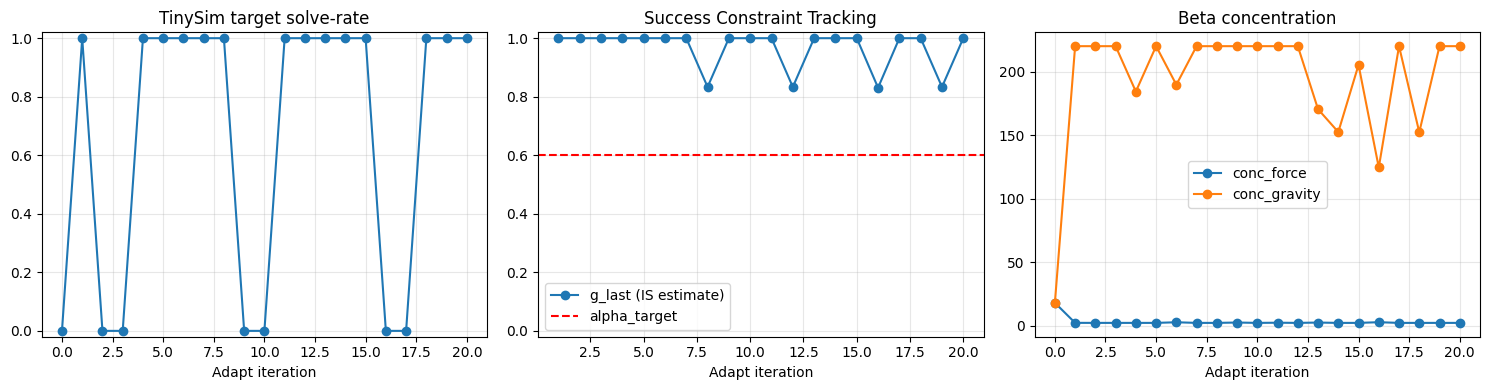

In [12]:
# choose which result to visualize
result = edge_result  # or prototype_result / edge_result
hist = result['history']

iters = [r['iter'] for r in hist]
fvals = [r['target_solve_rate'] for r in hist]
glast = [r['g_last'] for r in hist]
cf = [r['conc_force_end'] for r in hist]
cg = [r['conc_gravity_end'] for r in hist]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(iters, fvals, marker='o')
axes[0].set_title('TinySim target solve-rate')
axes[0].set_xlabel('Adapt iteration')
axes[0].set_ylim(-0.02, 1.02)
axes[0].grid(True, alpha=0.3)

axes[1].plot(iters, glast, marker='o', label='g_last (IS estimate)')
axes[1].axhline(ALPHA_TARGET, color='r', linestyle='--', label='alpha_target')
axes[1].set_title('Success Constraint Tracking')
axes[1].set_xlabel('Adapt iteration')
axes[1].set_ylim(-0.02, 1.02)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(iters, cf, marker='o', label='conc_force')
axes[2].plot(iters, cg, marker='o', label='conc_gravity')
axes[2].set_title('Beta concentration')
axes[2].set_xlabel('Adapt iteration')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

## 11) Playback Best Policy in TinySim (Inline Animation)

In [ ]:
def render_tinysim_state_frame(position, min_position=-1.2, max_position=0.6, goal_position=0.5):
    fig, ax = plt.subplots(figsize=(6, 4), dpi=100)
    x = np.linspace(min_position, max_position, 500)
    y = np.sin(3 * x)
    car_y = np.sin(3 * position)

    ax.plot(x, y, color='black', linewidth=2)
    ax.scatter([position], [car_y], s=200, c='crimson', zorder=5)

    gx = goal_position
    gy = np.sin(3 * gx)
    ax.plot([gx, gx], [gy, gy + 0.2], color='black', linewidth=2)
    ax.fill([gx, gx + 0.06, gx], [gy + 0.2, gy + 0.17, gy + 0.14], color='gold')

    ax.set_xlim(min_position - 0.05, max_position + 0.05)
    ax.set_ylim(-1.25, 1.25)
    ax.set_title('Best BO+DORAEMON Policy in TinySim')
    ax.set_xlabel('Position')
    ax.set_ylabel('Height')
    ax.grid(alpha=0.3)

    from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
    canvas = FigureCanvas(fig)
    canvas.draw()
    frame = np.asarray(canvas.buffer_rgba())[..., :3].copy()
    plt.close(fig)
    return frame


def load_agent_from_checkpoint(path: str | Path, device: str = DEVICE) -> DQNAgent:
    payload = torch.load(str(path), map_location=device)
    agent = make_agent_from_hparams(payload.get('hparams'), device=device)
    agent.load_payload(payload)
    return agent


def record_best_policy_frames(agent: DQNAgent, target_params: dict, max_steps: int = 200):
    sim_env = MountainCarEnv()
    sim_env.force = float(target_params['force'])
    sim_env.gravity = float(target_params['gravity'])

    state = sim_env.reset()
    obs = np.array([state['position'], state['velocity']], dtype=np.float32)

    frames = [
        render_tinysim_state_frame(
            position=float(state['position']),
            min_position=sim_env.min_position,
            max_position=sim_env.max_position,
            goal_position=sim_env.goal_position,
        )
    ]

    done = bool(state['done'])
    steps = 0

    while (not done) and steps < max_steps:
        a = agent.act(obs, training=False)
        state = sim_env.step(a)
        obs = np.array([state['position'], state['velocity']], dtype=np.float32)
        done = bool(state['done'])
        steps += 1

        frames.append(
            render_tinysim_state_frame(
                position=float(state['position']),
                min_position=sim_env.min_position,
                max_position=sim_env.max_position,
                goal_position=sim_env.goal_position,
            )
        )

    summary = {
        'solved': bool(done),
        'steps': int(steps),
        'final_position': float(state['position']),
        'n_frames': len(frames),
    }
    return frames, summary


best_agent = load_agent_from_checkpoint(result['best_checkpoint'], device=DEVICE)
frames, summary = record_best_policy_frames(best_agent, target_params=TARGET_PARAMS, max_steps=tau_steps)

fig, ax = plt.subplots(figsize=(6, 4))
ax.axis('off')
img = ax.imshow(frames[0])

def update(frame):
    img.set_data(frame)
    return [img]

ani = animation.FuncAnimation(fig, update, frames=frames, interval=25, blit=True)
plt.close(fig)

print(summary)
HTML(ani.to_jshtml())
